In [10]:
import shap
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

In [ ]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data , housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.15, max_depth=5, random_state=42)
model.fit(X_train, y_train)
columns = X.columns
for col in columns:
    shap.partial_dependence_plot(
    col,
    model.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    
)

La dépendance partielle montre la relation entre une ou plusieurs features et la prédiction moyenne du modèle, tout en neutralisant l'effet des autres features. Elle répond à la question : Comment les prédictions changent-elles en fonction d'une caractéristique donnée, en moyenne ? Cette approche suppose que les caractéristiques sont indépendantes, ce qui n'est pas toujours vrai dans les données réelles.

**MedInc** : Valeur des maisons augmente avec le revenu médian.
**HouseAge** (Relation en U) : maisons récentes plus chères, 5 à 20 ans moins, puis valeur remonte pour maisons anciennes.
**AveRooms** : Valeur augmente avec le nombre de pièces : 1 à 3 pièces 200000 dollars, 3 à 60 pièces 260000 dollars, plus de 60 pièces 340000 dollars.
**AveBedrms** : 1 à 10 chambres 230000 dollars, 10 à 17 chambres 220000 dollars, plus de 17 chambres 235000 dollars.
**Population** : Impact limité, valeur augmente légèrement puis stagne.
**AveOccup** : Influence négligeable.
**Latitude** : Valeur diminue en allant vers le nord.
**Longitude** : Valeur diminue en s’éloignant de la côte californienne.

ExactExplainer explainer: 4129it [06:31, 10.23it/s]                          


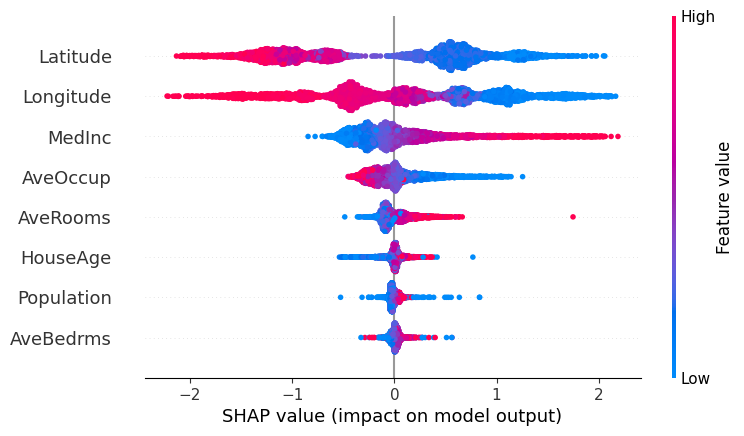

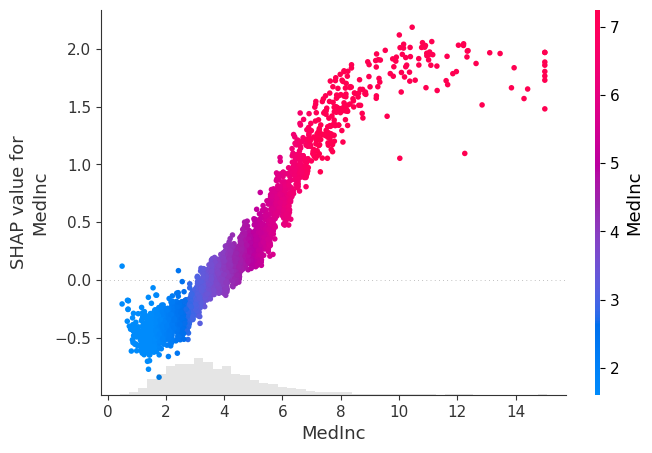

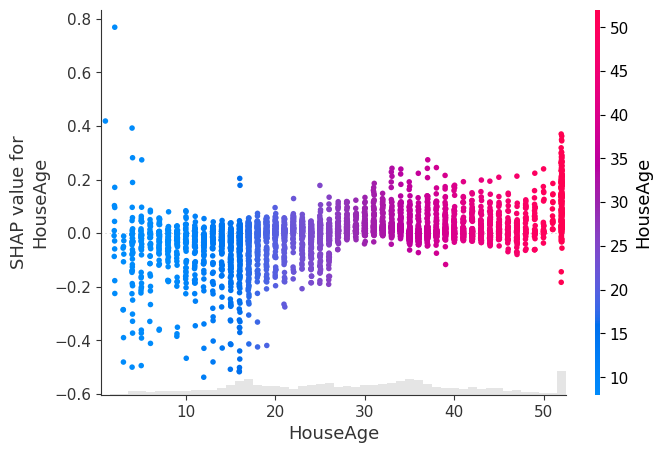

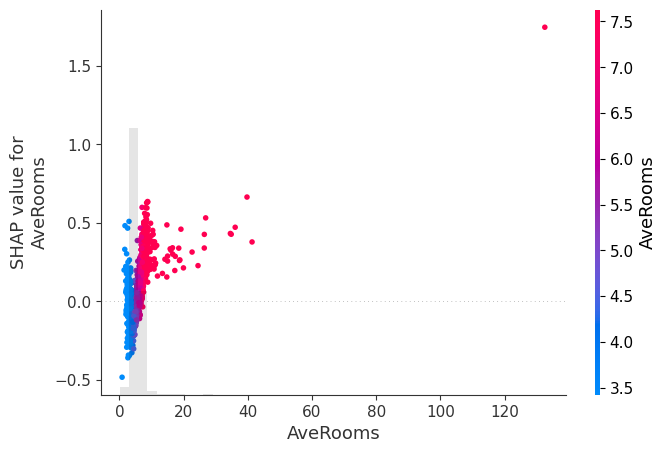

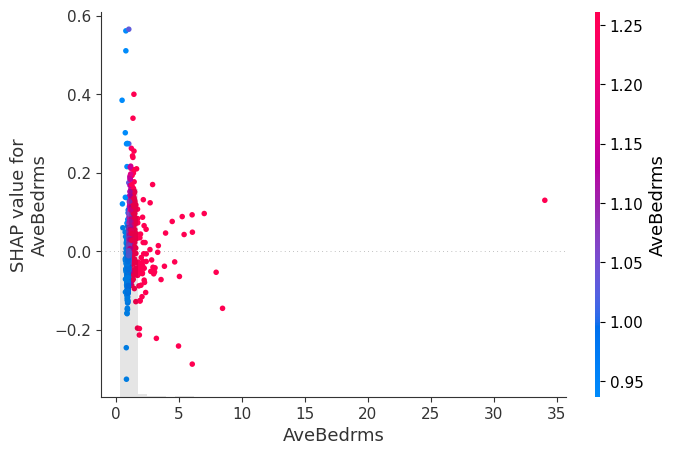

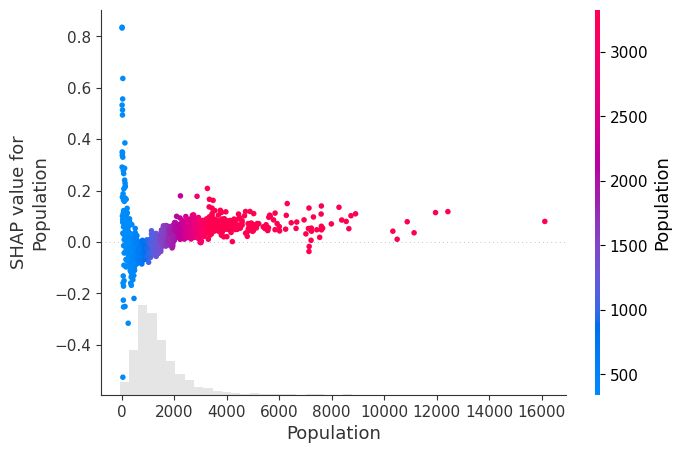

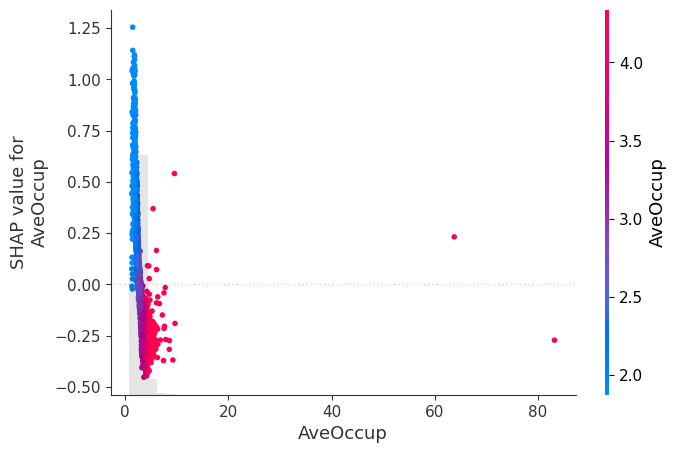

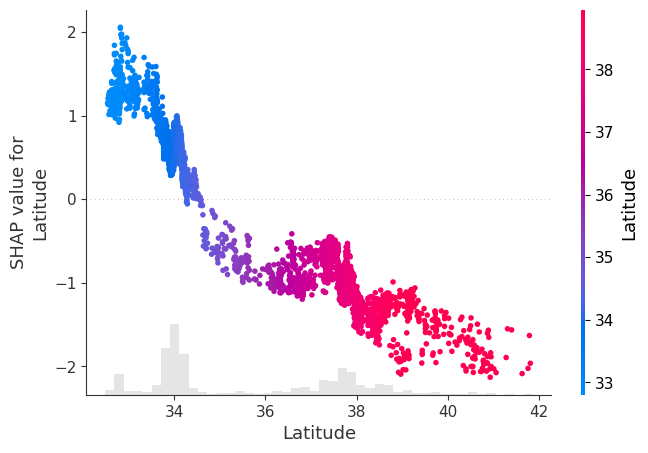

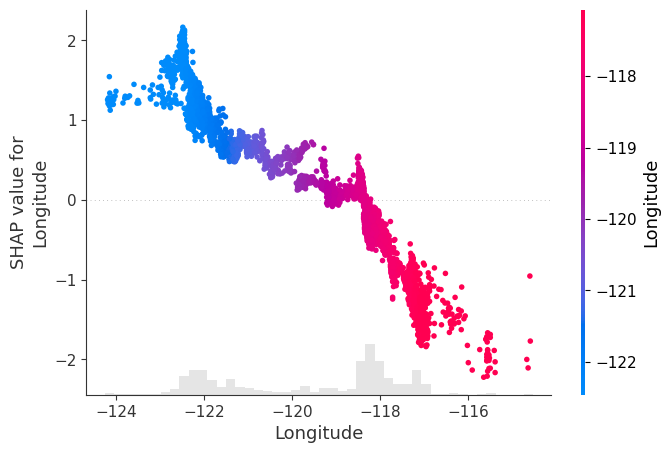

In [13]:
explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)
for col in columns:
    shap.plots.scatter(shap_values[:, col], color=shap_values[:, col])

Les valeurs SHAP mesurent la contribution exacte de chaque caractéristique à la prédiction d'une observation spécifique, en utilisant les valeurs de Shapley issues de la théorie des jeux. Pour une observation donnée, les valeurs SHAP calculent la différence entre la prédiction obtenue avec et sans chaque caractéristique, en considérant toutes les combinaisons possibles. Les valeurs SHAP sont additives : la somme des contributions de toutes les caractéristiques est égale à la prédiction finale moins la valeur de base (expected value). Elles répondent à la question : Pourquoi ce modèle a-t-il fait cette prédiction pour cette observation ? Exemple : Pour une observation où la prédiction est élevée, les valeurs SHAP vous diront quelles caractéristiques ont poussé la prédiction à augmenter et de combien, lesquelles l'ont fait baisser. Les valeurs SHAP prennent en compte les interactions entre caractéristiques. Applicables aux explications locales et globales.

Le graphique des valeurs SHAP présenté ci-dessus confirme les résultats obtenus lors de l'analyse des dépendances partielles. Les variables qui influencent le plus les prédictions du modèle sont **Latitude**, **Longitude**, et **MedInc**. Ces caractéristiques jouent un rôle clé dans la détermination des valeurs médianes des maisons. Ensuite, des variables comme **AveOccup** et **AveRooms** exercent une influence moindre, mais non négligeable. Enfin, **HouseAge**, **Population**, et **AveBedrms** ont une contribution très faible, indiquant qu'elles impactent peu les prédictions du modèle.

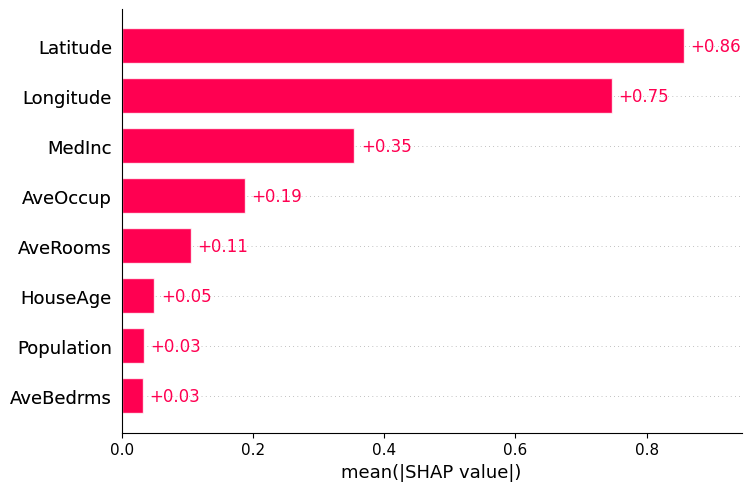

In [27]:
shap.plots.bar(shap_values, max_display=8)

Ce graphique montre qu’en moyenne, les caractéristiques **Latitude**, **Longitude**, **MedInc**, **AveOccup**, **AveRooms**, **HouseAge**, **Population**, et **AveBedrms** contribuent respectivement, en valeur absolue, à hauteur de **0,86**, **0,75**, **0,35**, **0,19**, **0,11**, **0,05**, **0,03**, et **0,03** à la prédiction du modèle par rapport à la baseline. Ces résultats confirment l’importance relative des variables identifiées précédemment, avec une influence majeure des trois premières caractéristiques (**Latitude**, **Longitude**, et **MedInc**) et une contribution plus marginale des autres.

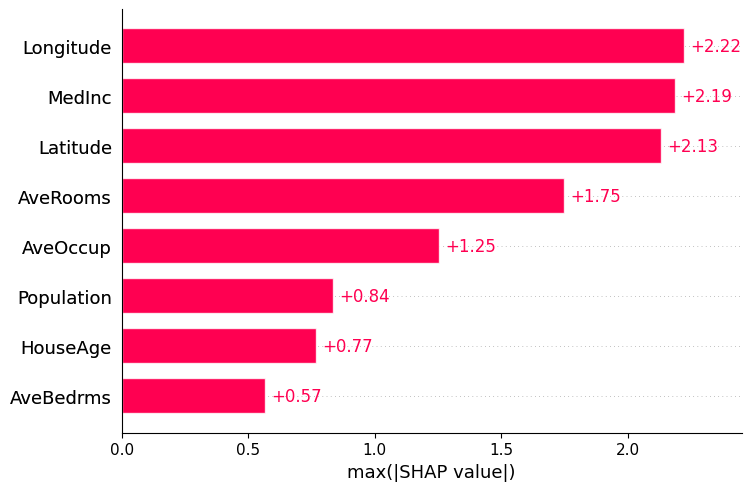

In [28]:
shap.plots.bar(shap_values.abs.max(0), max_display=8)

Ce graphique illustre que les caractéristiques **Longitude**, **MedInc**, **AveRooms**, **AveOccup**, **HouseAge**, **Population**, et **AveBedrms** contribuent, en valeur absolue, respectivement à hauteur de **2.22, 2.19, 2.13, 1.75, 1.25, 0.84, 0.84, 0.77, et 0.51** à la prédiction du modèle par rapport à la baseline.

* **Longitude**, **MedInc** et **AveRooms** affichent les contributions les plus élevées, toutes proches de **2**. Cela montre que la **localisation géographique** (longitude) et le **revenu médian des ménages**, ainsi que le **nombre moyen de pièces par logement**, jouent un rôle déterminant dans les prédictions du modèle.
* **AveOccup** et **HouseAge** présentent des contributions intermédiaires : leur influence est significative mais reste secondaire comparée aux variables majeures. Cela traduit par exemple l’importance de la densité d’occupation et de l’ancienneté des logements dans la variation des prix.
* **Population**, **AveBedrms** et les autres variables étudiées affichent des contributions plus faibles, bien que non négligeables. Leur impact est plus diffus, venant compléter l’effet des variables principales.